In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

sns.set_style("whitegrid")

import matplotlib

# set font size to 16
matplotlib.rcParams.update({"font.size": 16})

SEED = 4

In [6]:
n_runs = 100
# ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "UDPLag", "Syn"]
start_type = "NetBIOS"

#Use the csv files again
#Load accuracy, precision, recall and f1 score
def load_dict_from_csv(filename):
    df = pd.read_csv(filename)
    nested_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        nested_dict.setdefault(run, {})[method] = group['Value'].tolist()
    return nested_dict

def get_summary(loaded_dict):
    methods = list(loaded_dict[0].keys())
    summary_dict = {}
    for method in methods:
        all_runs = np.array([loaded_dict[run][method] for run in range(n_runs)]) # shape: (100, array_length)
        # Compute statistics
        mean_values = np.mean(all_runs, axis=0)
        plow_values = np.percentile(all_runs, 10, axis=0)
        phigh_values = np.percentile(all_runs, 90, axis=0)
        # Store in nested structure for easy plotting
        summary_dict[method] = {
            "mean": mean_values.tolist(),
            "plow": plow_values.tolist(),
            "phigh": phigh_values.tolist()
        }
    return summary_dict

def compute_fpr(precision, recall, accuracy):
    p = precision
    r = recall
    A = accuracy
    
    # avoid division by zero
    if p == 0 or r == 0 or A == 1:
        return 0
    
    k = 1 + (1 - p)/p + (1 - r)/r
    
    numerator = (1 - p) / p
    denominator = numerator + (A * k - 1) / (1 - A)

    divi = numerator / denominator
    return divi


accuracy_dict_loaded = load_dict_from_csv( f"./results_dictionaries/accuracy_dict_{start_type}_{n_runs}.csv")
precision_dict_loaded = load_dict_from_csv( f"./results_dictionaries/precision_dict_{start_type}_{n_runs}.csv")
recall_dict_loaded = load_dict_from_csv( f"./results_dictionaries/recall_dict_{start_type}_{n_runs}.csv")

# Build FPR dictionary (same structure as your metrics)
fpr_dict = {}

for run in range(n_runs):
    fpr_dict[run] = {}
    for method in precision_dict_loaded[run].keys():
        precisions = precision_dict_loaded[run][method]
        recalls = recall_dict_loaded[run][method]
        accuracies = accuracy_dict_loaded[run][method]
        
        fprs = [compute_fpr(p, r, a) 
                for p, r, a in zip(precisions, recalls, accuracies)]
        
        fpr_dict[run][method] = fprs


# Summaries
fpr_summary = get_summary(fpr_dict)

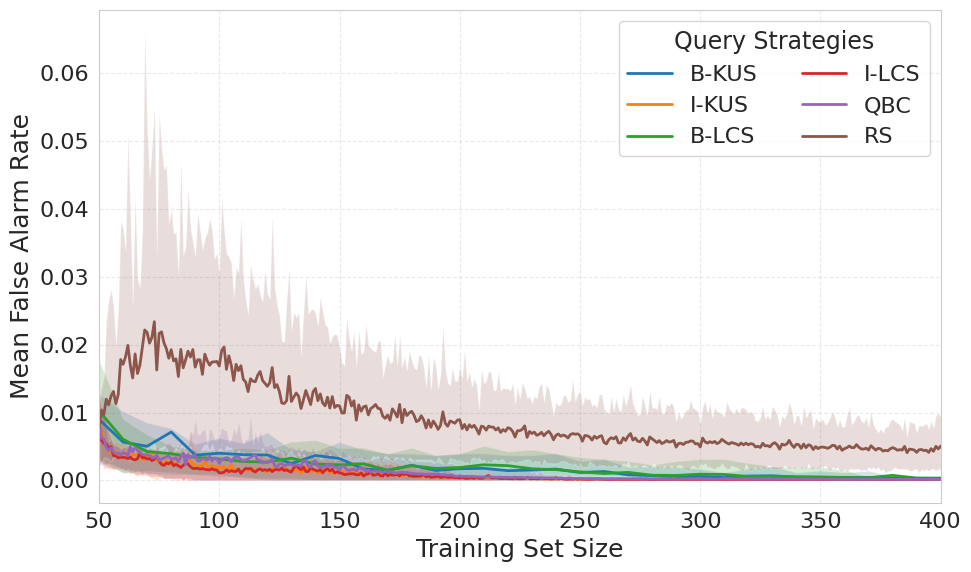

In [7]:
def plot_summary(dict_summary, metric_name):
    dataset_size = np.array(range(50, 401))
    dataset_size_batch = np.array(range(50, 401, 10))
    #method_label = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]
    method_label = ["B-KUS", "I-KUS", "B-LCS", "I-LCS", "QBC", "RS"]

    #Plot
    plt.figure(figsize=(10, 6))
    # Plot each method
    for i, (method, stats) in enumerate(dict_summary.items()):
        mean = np.array(stats["mean"])
        plow = np.array(stats["plow"])
        phigh = np.array(stats["phigh"])
        if len(mean) == len(dataset_size_batch):
            plt.plot(dataset_size_batch, mean,  linewidth=2, label=method_label[i])
            plt.fill_between(dataset_size_batch, plow, phigh, alpha=0.2)
        else:
            plt.plot(dataset_size, mean, linewidth=2, label=method_label[i])    
            plt.fill_between(dataset_size, plow, phigh, alpha=0.2)

    # Labels, legend, and styling
    plt.xlim(50, 400)
    plt.xticks(fontsize = 16)   
    plt.yticks(fontsize = 16)
    plt.xlabel("Training Set Size", fontsize=18)
    plt.ylabel(f"Mean {metric_name}", fontsize=18)
    #plt.title(f"Mean {metric_name} and 10-90 Percentile over 100 Runs for Initial Type " + start_type, fontsize=14, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(fontsize=16, ncol = 2, title = "Query Strategies", title_fontsize=17)
    plt.tight_layout()
    plt.savefig(f"./PROACT_{start_type}/{metric_name}_{start_type}.pdf", bbox_inches='tight')
    plt.show()

# Plot summaries
plot_summary(fpr_summary, "False Alarm Rate")


In [8]:

# Find data sizes where FPR drops below thresholds
def find_datasize_at_fpr_threshold(fpr_summary, thresholds=[0.001, 0.0002]):
    """
    Find the data size where FPR drops below specified thresholds for each method.
    
    Args:
        fpr_summary: Dictionary with method names as keys and stats (mean, plow, phigh) as values
        thresholds: List of FPR thresholds to find
    
    Returns:
        Dictionary with results for each threshold and method
    """
    dataset_size = np.array(range(50, 401))
    dataset_size_batch = np.array(range(50, 401, 10))
    method_label = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]
    
    # Mapping from old method labels to new display labels
    method_label_mapping = {
        "KU Batch": "B-KUS",
        "KU Single": "I-KUS",
        "Predict Proba Batch": "B-LCS",
        "Predict Proba Single": "I-LCS",
        "QBC": "QBC",
        "Random": "RS"
    }
    
    results = {}
    
    for threshold in thresholds:
        results[threshold] = {}
        
        for i, (method, stats) in enumerate(fpr_summary.items()):
            mean_fpr = np.array(stats["mean"])
            
            # Determine which dataset_size to use based on method
            if len(mean_fpr) == len(dataset_size_batch):
                data_sizes = dataset_size_batch
            else:
                data_sizes = dataset_size
            
            # Find where FPR drops below threshold
            indices_below_threshold = np.where(mean_fpr <= threshold)[0]
            
            # Get the mapped method label
            mapped_method_label = method_label_mapping[method_label[i]]
            
            if len(indices_below_threshold) > 0:
                first_idx = indices_below_threshold[0]
                datasize_at_threshold = data_sizes[first_idx]
                fpr_value = mean_fpr[first_idx]
                results[threshold][mapped_method_label] = {
                    "data_size": int(datasize_at_threshold),
                    "fpr_value": float(fpr_value)
                }
            else:
                results[threshold][mapped_method_label] = {
                    "data_size": "Not reached",
                    "fpr_value": float(mean_fpr[-1])
                }
    
    return results

# Find thresholds
fpr_thresholds = find_datasize_at_fpr_threshold(fpr_summary, [0.001, 0.0002])

# Display results
print("=" * 80)
print("Data Sizes Where False Positive Rate (FPR) Drops Below Thresholds")
print("=" * 80)

for threshold in [0.001, 0.0002]:
    print(f"\n📊 FPR Threshold: {threshold}")
    print("-" * 80)
    print(f"{'Query Strategy':<30} {'Training Set Size':<20} {'Actual FPR':<20}")
    print("-" * 80)
    
    for method, data in fpr_thresholds[threshold].items():
        data_size = data["data_size"]
        fpr_val = data["fpr_value"]
        if isinstance(data_size, int):
            print(f"{method:<30} {data_size:<20} {fpr_val:<20.6f}")
        else:
            print(f"{method:<30} {data_size:<20} {fpr_val:<20.6f}")
    print()

# Create a summary DataFrame for easier viewing
summary_data = []
for threshold in [0.001, 0.0002]:
    for method, data in fpr_thresholds[threshold].items():
        summary_data.append({
            "Threshold": threshold,
            "Algorithm": method,
            "Data Size": data["data_size"],
            "Actual FPR": data["fpr_value"]
        })

summary_df = pd.DataFrame(summary_data)
print("\n📈 Summary Table:")
print(summary_df.to_string(index=False))


Data Sizes Where False Positive Rate (FPR) Drops Below Thresholds

📊 FPR Threshold: 0.001
--------------------------------------------------------------------------------
Query Strategy                 Training Set Size    Actual FPR          
--------------------------------------------------------------------------------
B-KUS                          270                  0.000806            
I-KUS                          159                  0.000815            
B-LCS                          280                  0.000756            
I-LCS                          152                  0.000843            
QBC                            181                  0.000975            
RS                             Not reached          0.005058            


📊 FPR Threshold: 0.0002
--------------------------------------------------------------------------------
Query Strategy                 Training Set Size    Actual FPR          
---------------------------------------------------------